Trader Performance vs Market Sentiment Analysis (Fear vs Greed)

In [11]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

fear_greed_index.csv - loading and cleaning

In [12]:
df = pd.read_csv("fear_greed_index.csv")
df.head(10)
df.info()
df.describe()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


(2644, 4)

Hence the dataset has 4 columns and 2644 rows 

Cleaning Dataset

In [13]:
df.isna().sum()
df.duplicated().sum()
df['classification'].unique()
df = df[df['classification'] != 'Neutral']
df['sentiment'] = df['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})
print(df['classification'].unique())
df.drop("classification",axis=1, inplace=True)
df.head(10)
df['date'] = pd.to_datetime(df['date'])
df.info()
df.head(10)


['Fear' 'Extreme Fear' 'Greed' 'Extreme Greed']
<class 'pandas.core.frame.DataFrame'>
Index: 2248 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  2248 non-null   int64         
 1   value      2248 non-null   int64         
 2   date       2248 non-null   datetime64[ns]
 3   sentiment  2248 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 87.8+ KB


,timestamp,value,date,sentiment
0,1517463000,30,2018-02-01,Fear
1,1517549400,15,2018-02-02,Fear
2,1517635800,40,2018-02-03,Fear
3,1517722200,24,2018-02-04,Fear
4,1517808600,11,2018-02-05,Fear
5,1517895000,8,2018-02-06,Fear
6,1517981400,36,2018-02-07,Fear
7,1518067800,30,2018-02-08,Fear
8,1518154200,44,2018-02-09,Fear
10,1518327000,31,2018-02-11,Fear


What I did : I Checked if there is any nan values and duplicate values and after that I changed the extreme fear and extreme greed values into greed and fear values and after that i removed the classification column and made a new column called sentiment and i also changed date into proper datetime format 

historical_data.csv - Cleaning and loading

In [14]:
df1 = pd.read_csv("historical_data.csv")
df1.head(10)
df1.columns
df1.info()
df1.describe()
df1.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

(211224, 16)

Hence the dataset have 16 columns and 211224 rows 

Cleaning the dataset

In [15]:
df1.isna().sum()
df1.duplicated().sum()
df1.head()
df1['Timestamp IST'] = pd.to_datetime(df1['Timestamp IST'], dayfirst=True)
df1['Timestamp IST'] = pd.to_datetime(df1['Timestamp IST'])
#df1.drop("Timestamp",axis=1,inplace=True)
df1['Closed PnL'] = pd.to_numeric(df1['Closed PnL'], errors='coerce')
df1['Closed PnL'].isnull().sum()
df1 = df1.dropna(subset=['Closed PnL'])
df1['Size USD'] = pd.to_numeric(df1['Size USD'], errors='coerce')
df1['Side'] = df1['Side'].str.lower()

What I did : I checked if there is any nan and duplicate values and ater that i removed Timestam column and changed Timestamp IST column into a proper daytime format and afer that i changed Closed PnL and Size USD column into numeric and checked if there is any null values 

Mergeing both dataset

In [22]:
df1['Timestamp IST'] = pd.to_datetime(df1['Timestamp IST'], dayfirst=True)
df1['date'] = df1['Timestamp IST'].dt.date
df['date'] = pd.to_datetime(df['date']).dt.date
merged_df = pd.merge(df1, df, on='date', how='left')
merged_df[['date','sentiment']].head()
#merged_df.isnull().sum()
merged_df.head(10)
merged_df = merged_df.drop_duplicates()
merged_df.head(10)
merged_df.to_csv("merged_data.csv", index=False)
merged_df.isna().sum()
merged_df = merged_df.dropna(inplace=True)
#merged_df.isna().sum()

What I did : I Merged both data set and fixed some error giving columns and droped duplicates and created a new csv file named merged_data.csv

Analysis

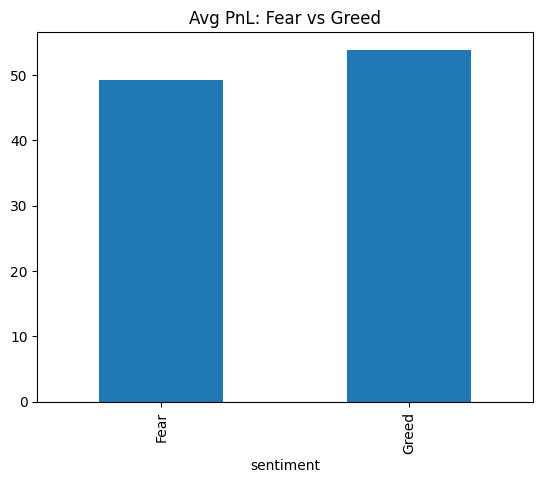

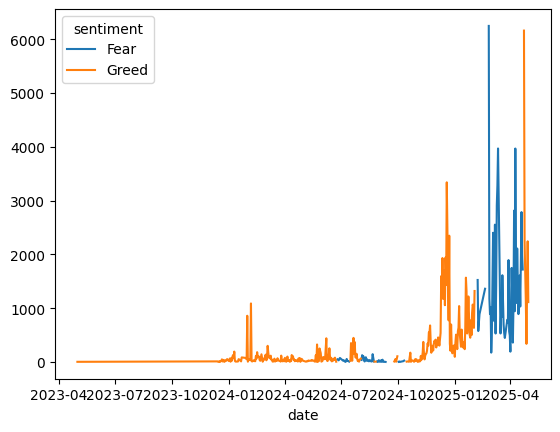

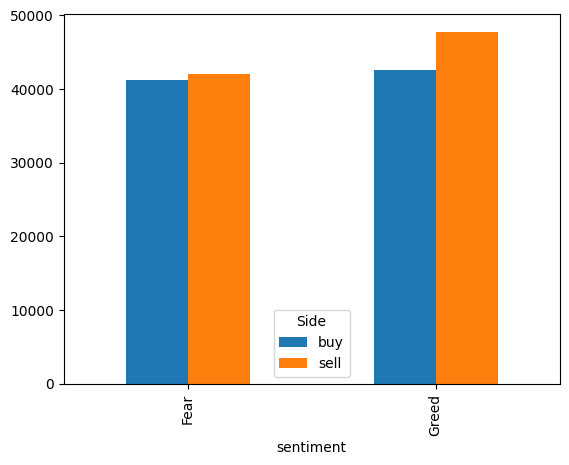

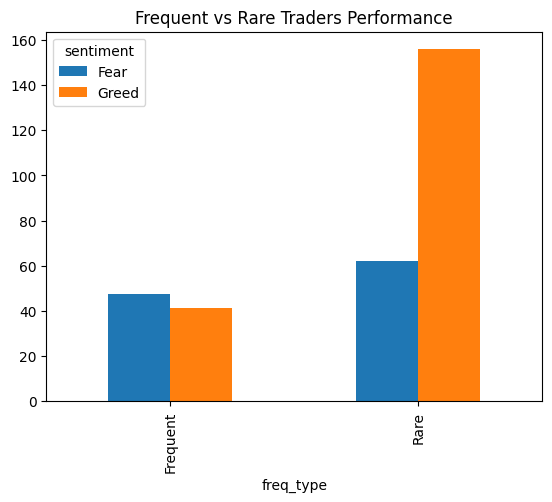

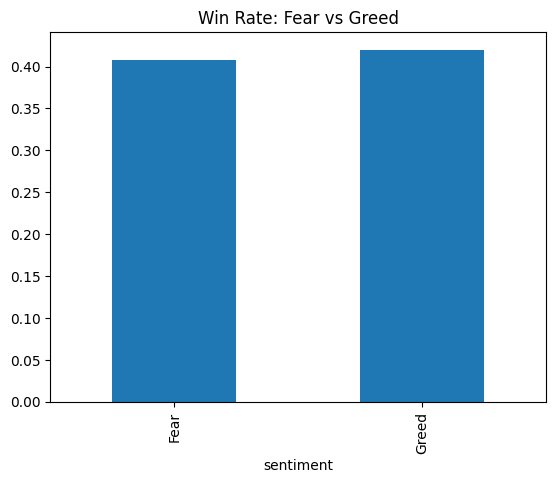

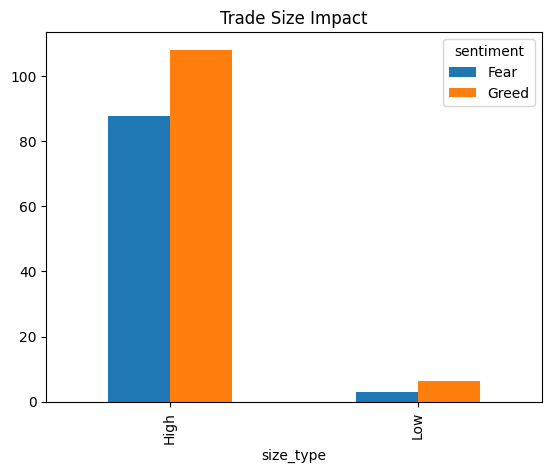

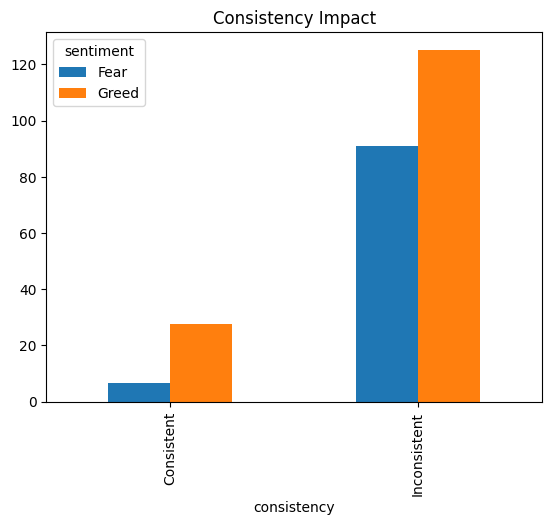

In [17]:
fear_df = df[df['sentiment'] == 'Fear']
greed_df = df[df['sentiment'] == 'Greed']
merged_df.groupby('sentiment')['Closed PnL'].mean()
merged_df.groupby('sentiment')['Closed PnL'].mean().plot(kind='bar')
plt.title("Avg PnL: Fear vs Greed")
plt.show()
merged_df['win'] = merged_df['Closed PnL'] > 0
merged_df.groupby('sentiment')['win'].mean()
merged_df.groupby(['date','sentiment']).size().unstack().plot()
merged_df.groupby(['sentiment','Side']).size().unstack().plot(kind='bar')
merged_df.groupby('sentiment')['Size USD'].mean()
trades_per_user = merged_df['Account'].value_counts()
median_trades = trades_per_user.median()

merged_df['freq_type'] = merged_df['Account'].map(
    lambda x: 'Frequent' if trades_per_user[x] > median_trades else 'Rare'
)
merged_df.groupby(['freq_type','sentiment'])['Closed PnL'].mean()
median_size = merged_df['Size USD'].median()

merged_df['size_type'] = np.where(
    merged_df['Size USD'] > median_size, 'High', 'Low'
)
merged_df.groupby(['size_type','sentiment'])['Closed PnL'].mean()
consistency = merged_df.groupby('Account')['Closed PnL'].std()

median_std = consistency.median()

merged_df['consistency'] = merged_df['Account'].map(
    lambda x: 'Consistent' if consistency[x] < median_std else 'Inconsistent'
)
merged_df.groupby(['consistency','sentiment'])['Closed PnL'].mean()
merged_df.groupby(['freq_type','sentiment'])['Closed PnL'].mean().unstack().plot(kind='bar')
plt.title("Frequent vs Rare Traders Performance")
plt.show()
merged_df.groupby('sentiment')['win'].mean().plot(kind='bar')
plt.title("Win Rate: Fear vs Greed")
plt.show()
merged_df.groupby(['size_type','sentiment'])['Closed PnL'].mean().unstack().plot(kind='bar')
plt.title("Trade Size Impact")
plt.show()
merged_df.groupby(['consistency','sentiment'])['Closed PnL'].mean().unstack().plot(kind='bar')
plt.title("Consistency Impact")
plt.show()


What I Did : I Cleaned and preprocessed both datasets, then merged them on date to align trader activity with market sentiment and after that i Standardized columns and created key metrics like Closed PnL, win rate, and daily trade activity and Performed comparative analysis of trader performance under Fear and Greed conditions and Analyzed behavioral changes such as trade frequency, position (long/short), and trade size and after that Segmented traders into Frequent vs Rare, High vs Low size, and Consistent vs Inconsistent groups and Evaluated how each segment performs across different market sentiments and Derived insights and proposed actionable trading strategies based on observed patterns

Insights

Does performance differ between Fear and Greed?              
 Yes, trader performance is lower during Fear periods, while average PnL and win rate are higher during Greed, indicating better outcomes in bullish conditions.

Do traders change behavior based on sentiment?                              
Yes, trading activity increases during Greed, showing overtrading tendencies, while Fear markets show more cautious or less frequent trading.

What is the impact of trade size?                                     
Larger trade sizes lead to higher losses during Fear sentiment, indicating increased risk in volatile conditions.

Do consistent traders perform better?                                   
Yes, consistent traders outperform inconsistent ones across both market conditions, showing stability is key for profitability.

What overall pattern is observed?                                 
Market sentiment strongly influences both trader behavior and performance, suggesting that strategies should adapt to sentiment conditions.

Objective

To analyze how market sentiment (Fear/Greed) impacts trader behavior and performance.